First 5 Rows of Dataset:
   patient_id     sex  birth_year      country   region      infection_reason  \
0           1    male        1998  South Korea    Seoul  contact with patient   
1           2  female        1985  South Korea    Busan         travel abroad   
2           3    male        1970  South Korea    Daegu        church cluster   
3           4  female        1995  South Korea    Seoul  contact with patient   
4           5    male        2001  South Korea  Incheon         travel abroad   

   infection_order  infected_by  contact_number confirmed_date released_date  \
0                1          NaN              12     2020-01-20    2020-02-05   
1                2          1.0               8     2020-02-01    2020-02-16   
2                3          2.0              20     2020-02-10           NaN   
3                2          1.0              10     2020-02-12    2020-02-28   
4                1          NaN               5     2020-02-15    2020-03-01   

  decea

<Figure size 800x500 with 0 Axes>

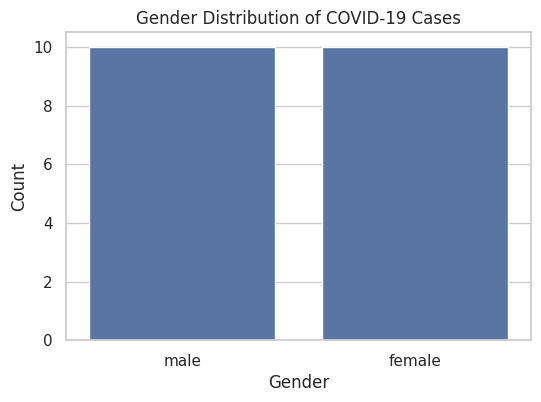

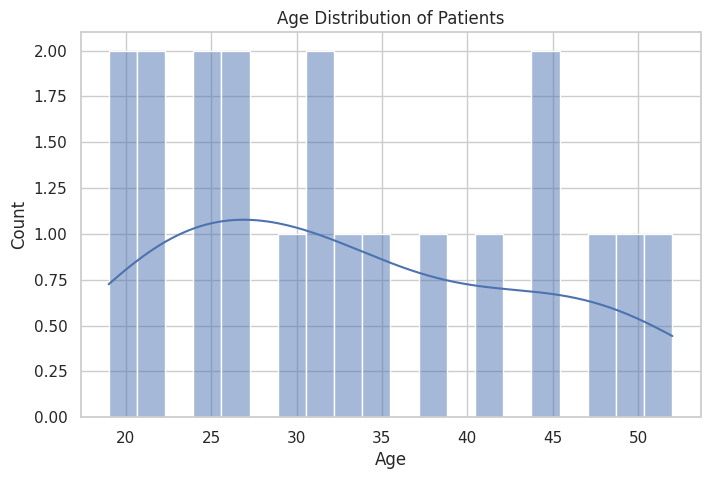

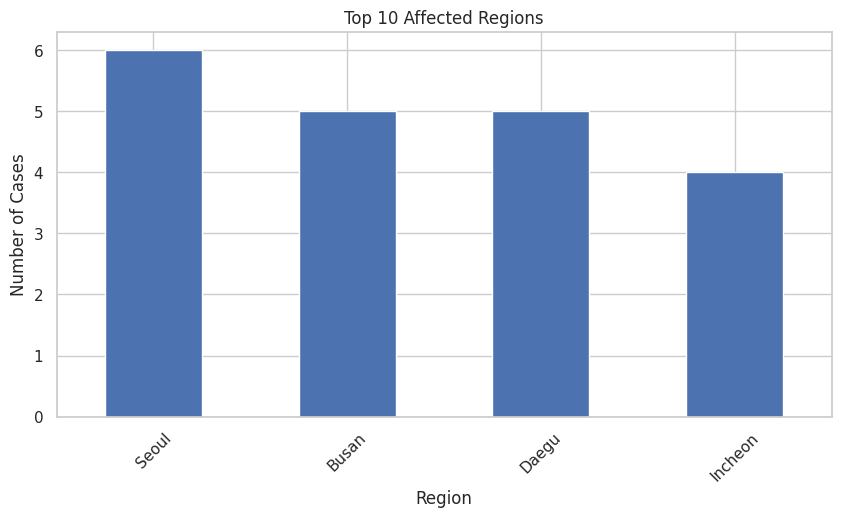

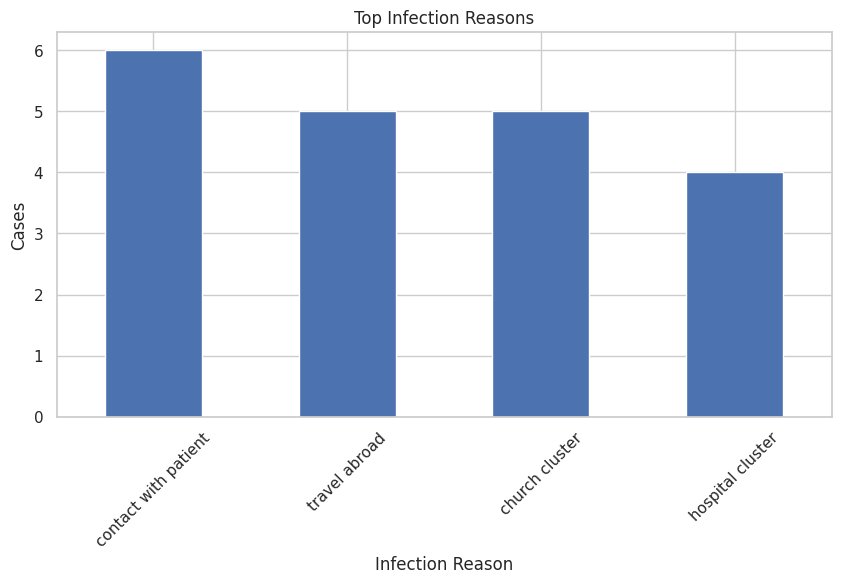

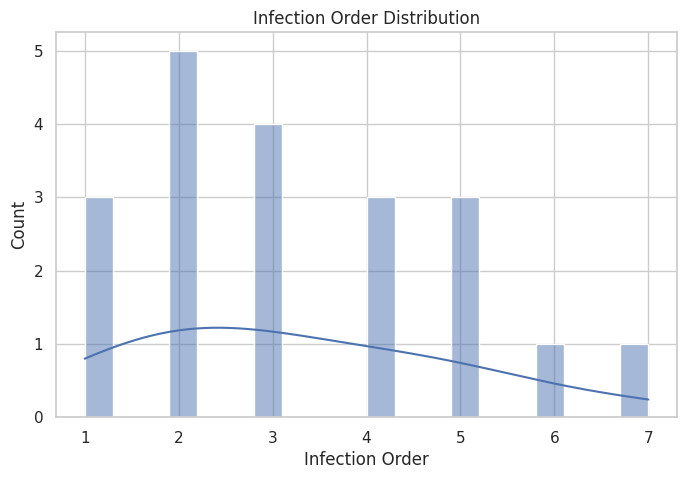

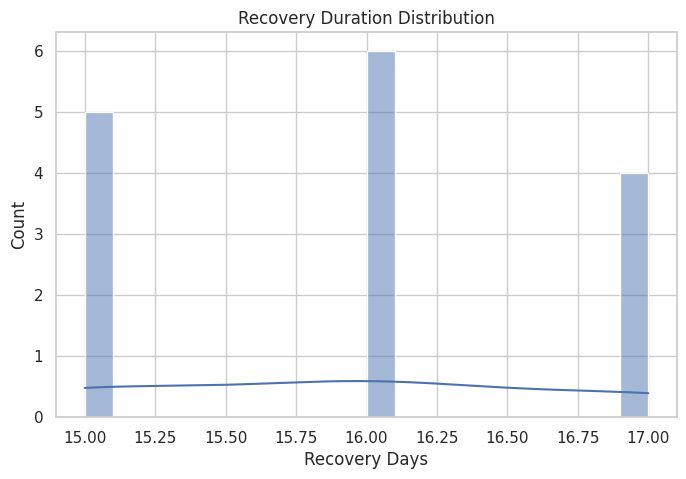

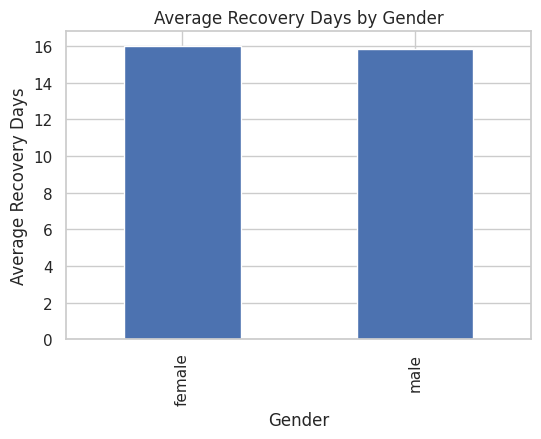

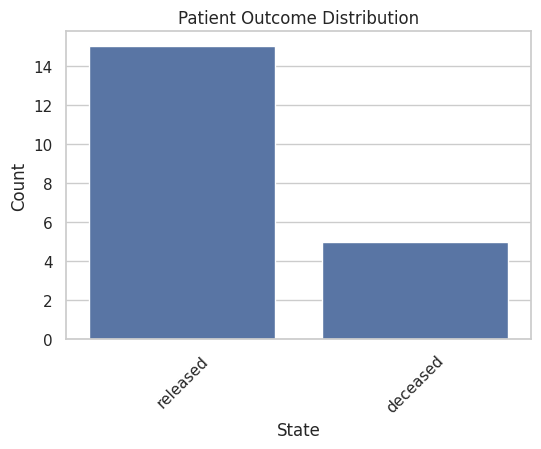

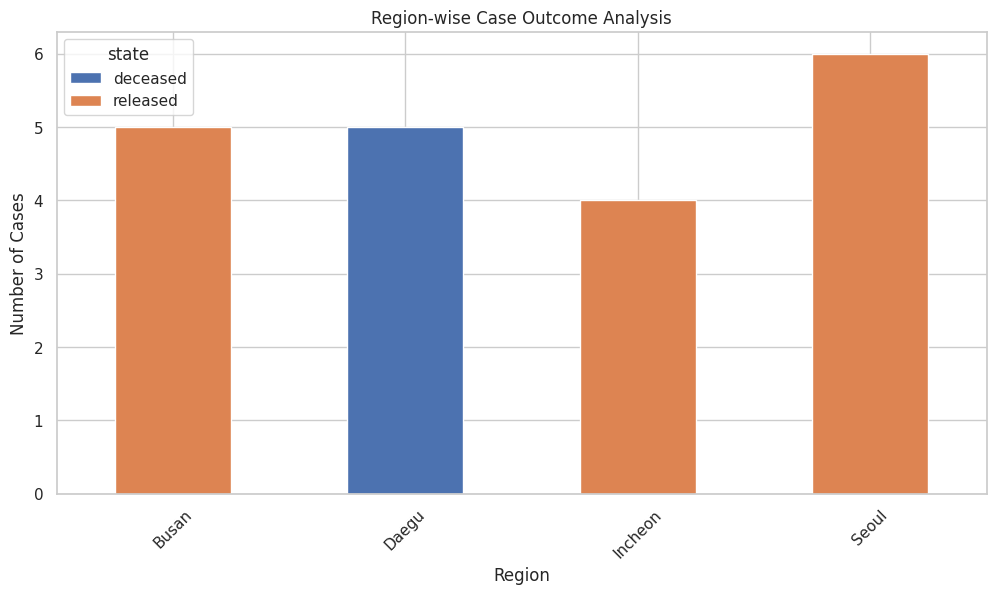


DESCRIPTIVE STATISTICS

Age Statistics:
count    20.000000
mean     33.200000
std      10.571063
min      19.000000
25%      24.750000
50%      31.500000
75%      42.500000
max      52.000000
Name: age, dtype: float64

Recovery Days Statistics:
count    15.000000
mean     15.933333
std       0.798809
min      15.000000
25%      15.000000
50%      16.000000
75%      16.500000
max      17.000000
Name: recovery_days, dtype: float64

Contact Number Statistics:
count    20.000000
mean     12.850000
std       5.631444
min       5.000000
25%       8.750000
50%      11.500000
75%      16.500000
max      25.000000
Name: contact_number, dtype: float64

CORRELATION ANALYSIS

Correlation Matrix:
                      age  contact_number  infection_order  recovery_days
age              1.000000        0.818335         0.834188       0.455793
contact_number   0.818335        1.000000         0.827961       0.551088
infection_order  0.834188        0.827961         1.000000       0.642575
recovery_d

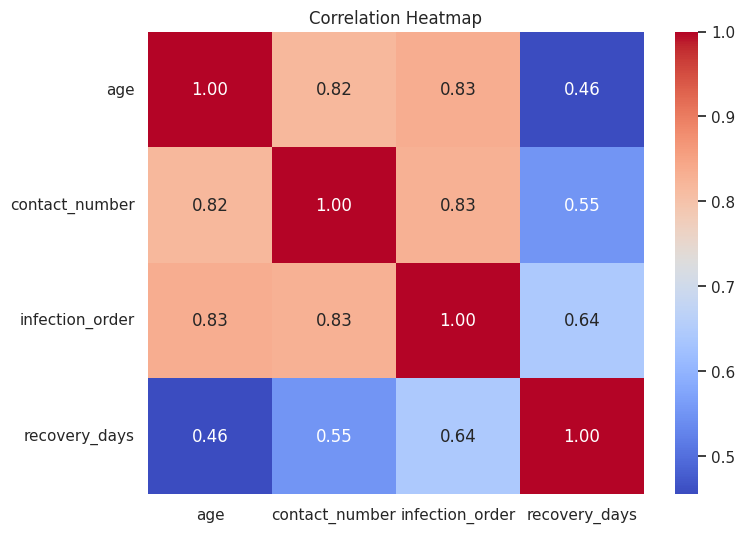


LINEAR REGRESSION RESULTS
Mean Absolute Error (MAE): 0.745853040304171
R2 Score: -2.6631847371175223


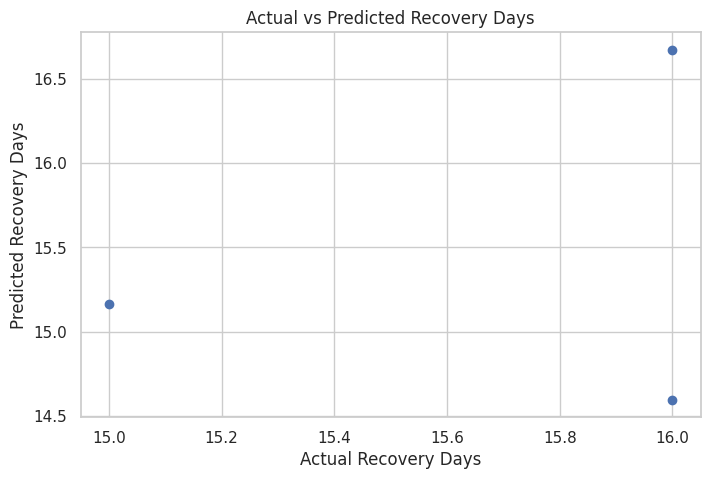


PROJECT COMPLETED SUCCESSFULLY

Possible Insights You Can Mention in Report:
1. Which gender has more cases
2. Which age group is most affected
3. Which region has highest number of cases
4. Main infection reasons
5. Average recovery duration
6. Relationship between age/contact number and recovery days
7. Predictive analysis using linear regression



In [3]:

# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
plt.figure(figsize=(8,5))
sns.set(style="whitegrid")

# STEP 2: Load Dataset
df = pd.read_csv("covid_data.csv")

# STEP 3: Display Basic Information
print("First 5 Rows of Dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe(include='all'))

# STEP 4: Data Cleaning

# Convert date columns to datetime format
date_cols = ['confirmed_date', 'released_date', 'deceased_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Create Age column from birth_year
if 'birth_year' in df.columns:
    df['age'] = 2020 - df['birth_year']

# Create Recovery Days column
if 'confirmed_date' in df.columns and 'released_date' in df.columns:
    df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

# Remove unrealistic ages
if 'age' in df.columns:
    df.loc[(df['age'] < 0) | (df['age'] > 120), 'age'] = np.nan

# Remove negative recovery days
if 'recovery_days' in df.columns:
    df.loc[df['recovery_days'] < 0, 'recovery_days'] = np.nan

print("\nCleaned Data Preview:")
print(df.head())

# ============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# STEP 5: Gender Distribution
if 'sex' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='sex', data=df)
    plt.title("Gender Distribution of COVID-19 Cases")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.show()

# STEP 6: Age Distribution
if 'age' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['age'].dropna(), bins=20, kde=True)
    plt.title("Age Distribution of Patients")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()

# STEP 7: Region-wise Cases
if 'region' in df.columns:
    plt.figure(figsize=(10,5))
    df['region'].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Affected Regions")
    plt.xlabel("Region")
    plt.ylabel("Number of Cases")
    plt.xticks(rotation=45)
    plt.show()

# STEP 8: Infection Reason Analysis
if 'infection_reason' in df.columns:
    plt.figure(figsize=(10,5))
    df['infection_reason'].value_counts().head(10).plot(kind='bar')
    plt.title("Top Infection Reasons")
    plt.xlabel("Infection Reason")
    plt.ylabel("Cases")
    plt.xticks(rotation=45)
    plt.show()

# STEP 9: Infection Order Distribution
if 'infection_order' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['infection_order'].dropna(), bins=20, kde=True)
    plt.title("Infection Order Distribution")
    plt.xlabel("Infection Order")
    plt.ylabel("Count")
    plt.show()

# STEP 10: Recovery Days Distribution
if 'recovery_days' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['recovery_days'].dropna(), bins=20, kde=True)
    plt.title("Recovery Duration Distribution")
    plt.xlabel("Recovery Days")
    plt.ylabel("Count")
    plt.show()

# STEP 11: Average Recovery Days by Gender
if 'sex' in df.columns and 'recovery_days' in df.columns:
    plt.figure(figsize=(6,4))
    df.groupby('sex')['recovery_days'].mean().plot(kind='bar')
    plt.title("Average Recovery Days by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Average Recovery Days")
    plt.show()

# STEP 12: State / Outcome Distribution
if 'state' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='state', data=df)
    plt.title("Patient Outcome Distribution")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# STEP 13: Region-wise State Comparison
if 'region' in df.columns and 'state' in df.columns:
    region_state = df.groupby(['region', 'state']).size().unstack(fill_value=0)
    region_state.head(10).plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title("Region-wise Case Outcome Analysis")
    plt.xlabel("Region")
    plt.ylabel("Number of Cases")
    plt.xticks(rotation=45)
    plt.show()

# ============================================
# DESCRIPTIVE STATISTICS
# ============================================

print("\n==============================")
print("DESCRIPTIVE STATISTICS")
print("==============================")

if 'age' in df.columns:
    print("\nAge Statistics:")
    print(df['age'].describe())

if 'recovery_days' in df.columns:
    print("\nRecovery Days Statistics:")
    print(df['recovery_days'].describe())

if 'contact_number' in df.columns:
    print("\nContact Number Statistics:")
    print(df['contact_number'].describe())

# ============================================
# CORRELATION ANALYSIS
# ============================================

print("\n==============================")
print("CORRELATION ANALYSIS")
print("==============================")

corr_cols = ['age', 'contact_number', 'infection_order', 'recovery_days']
available_corr_cols = [col for col in corr_cols if col in df.columns]

if len(available_corr_cols) > 1:
    correlation_matrix = df[available_corr_cols].corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)

    plt.figure(figsize=(8,6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

# ============================================
# OPTIONAL: LINEAR REGRESSION MODEL
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model_cols = ['age', 'contact_number', 'infection_order', 'recovery_days']
available_model_cols = [col for col in model_cols if col in df.columns]

if len(available_model_cols) == 4:
    model_df = df[model_cols].dropna()

    if len(model_df) > 10:
        X = model_df[['age', 'contact_number', 'infection_order']]
        y = model_df['recovery_days']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        print("\n==============================")
        print("LINEAR REGRESSION RESULTS")
        print("==============================")
        print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
        print("R2 Score:", r2_score(y_test, y_pred))

        # Plot Actual vs Predicted
        plt.figure(figsize=(8,5))
        plt.scatter(y_test, y_pred)
        plt.xlabel("Actual Recovery Days")
        plt.ylabel("Predicted Recovery Days")
        plt.title("Actual vs Predicted Recovery Days")
        plt.show()
    else:
        print("\nNot enough clean data for Linear Regression model.")
else:
    print("\nRequired columns for Linear Regression not found.")

# ============================================
# FINAL INSIGHTS
# ============================================

print("\n==============================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("==============================")

print("""
Possible Insights You Can Mention in Report:
1. Which gender has more cases
2. Which age group is most affected
3. Which region has highest number of cases
4. Main infection reasons
5. Average recovery duration
6. Relationship between age/contact number and recovery days
7. Predictive analysis using linear regression
""")